In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pycisTopic.clust_vis import find_clusters, run_umap, run_tsne, plot_metadata

/home/jovyan/pycisTopic/src/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/opt/python4Jup/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NOTEBOOK_DIR = os.getcwd()
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

SAMPLE = "8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller"
CISTOPIC_OUT = os.path.join(REPO_ROOT, "results", "cistopic")
CTO_PATH = os.path.join(CISTOPIC_OUT, f"{SAMPLE}__cto_with_model.pkl")

with open(CTO_PATH, "rb") as f:
    cistopic_obj = pickle.load(f)

print(cistopic_obj)

2026-08-20 16:20:53,708	INFO util.py:155 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


CistopicObject from project 8k_mouse_cortex_ATACv2_nextgem_Chromium_Controller with n_cells × n_regions = 6111 × 1211806


In [3]:
find_clusters(
    cistopic_obj,
    target="cell",
    k=10,
    res=[0.6, 1.2],
    seed=555,
    scale=False,
    split_pattern="___",
)

run_umap(cistopic_obj, target="cell", scale=False, random_state=555)
run_tsne(cistopic_obj, target="cell", scale=False, random_state=555)

with open(CTO_PATH, "wb") as f:
    pickle.dump(cistopic_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

print("Clusters:", [c for c in cistopic_obj.cell_data.columns if "leiden" in c.lower()])
print("Reductions:", list(cistopic_obj.projections["cell"].keys()))

2026-08-20 16:21:56,073 cisTopic     INFO     Finding neighbours
Columns ['leiden_10_0.6'] will be overwritten
Columns ['leiden_10_1.2'] will be overwritten
2026-08-20 16:21:58,836 cisTopic     INFO     Running UMAP


/opt/python4Jup/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2026-08-20 16:22:54,783 cisTopic     INFO     Running TSNE
Clusters: ['leiden_10_0.6', 'leiden_10_1.2']
Reductions: ['UMAP', 'tSNE']


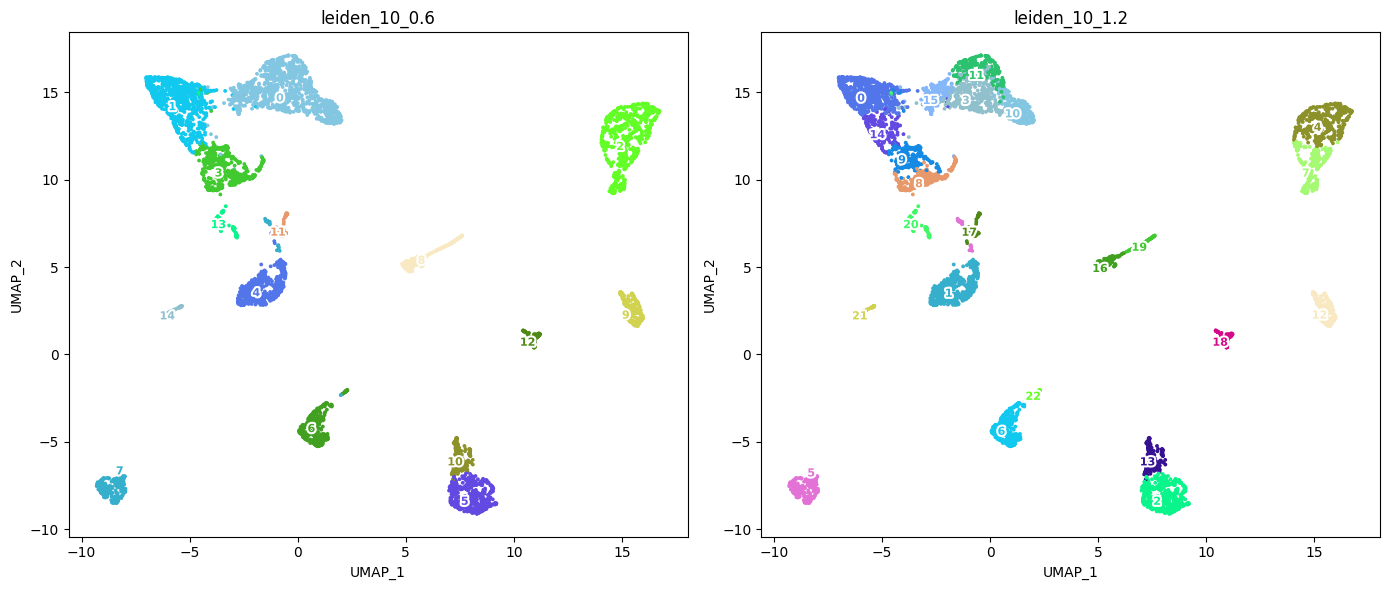

In [4]:
plot_metadata(
    cistopic_obj,
    reduction_name="UMAP",
    variables=["leiden_10_0.6", "leiden_10_1.2"],
    target="cell",
    num_columns=2,
    text_size=8,
    dot_size=3,
    figsize=(14, 6),
)

In [5]:
region_names = cistopic_obj.region_names
print(f"Total regions: {len(region_names)}")
print("Examples:", region_names[:3])
print()
print("Regions on chr18 around Csf1r:")
print([r for r in region_names if r.startswith("chr18:611") or r.startswith("18:611")][:10])

Total regions: 1211806
Examples: ['chr1:3003376-3003616', 'chr1:3005609-3005930', 'chr1:3008829-3009047']

Regions on chr18 around Csf1r:
['chr18:6111695-6112027', 'chr18:6114935-6115168', 'chr18:6119971-6120208', 'chr18:61100407-61100675', 'chr18:61101432-61101728', 'chr18:61103333-61103524', 'chr18:61105439-61105601', 'chr18:61105628-61105973', 'chr18:61106901-61107236', 'chr18:61107704-61107898']


In [6]:
CSF1R_PROMOTER = "chr18:61105628-61105973"
FIRE_ENHANCER = "chr18:61108478-61108826"

for name, region in [("Csf1r promoter", CSF1R_PROMOTER), ("FIRE enhancer", FIRE_ENHANCER)]:
    present = region in cistopic_obj.region_names
    print(f"{'OK' if present else 'MISSING':8s} {name:16s} {region}")

OK       Csf1r promoter   chr18:61105628-61105973
OK       FIRE enhancer    chr18:61108478-61108826


In [8]:
from pycisTopic.diff_features import impute_accessibility

imputed_acc = impute_accessibility(
    cistopic_obj,
    selected_cells=None,
    selected_regions=None,
    scale_factor=10**6,
    chunk_size=20000,
)

with open(os.path.join(CISTOPIC_OUT, f"{SAMPLE}__imputed_acc.pkl"), "wb") as f:
    pickle.dump(imputed_acc, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Imputed matrix: {imputed_acc.mtx.shape}")
print(f"Regions: {len(imputed_acc.feature_names)}")
print(f"Saved to {CISTOPIC_OUT}")

2026-08-20 16:35:16,796 cisTopic     INFO     Imputing region accessibility
2026-08-20 16:35:16,801 cisTopic     INFO     Impute region accessibility for regions 0-20000
2026-08-20 16:35:18,475 cisTopic     INFO     Impute region accessibility for regions 20000-40000
2026-08-20 16:35:20,282 cisTopic     INFO     Impute region accessibility for regions 40000-60000
2026-08-20 16:35:21,958 cisTopic     INFO     Impute region accessibility for regions 60000-80000
2026-08-20 16:35:23,742 cisTopic     INFO     Impute region accessibility for regions 80000-100000
2026-08-20 16:35:25,459 cisTopic     INFO     Impute region accessibility for regions 100000-120000
2026-08-20 16:35:27,206 cisTopic     INFO     Impute region accessibility for regions 120000-140000
2026-08-20 16:35:28,893 cisTopic     INFO     Impute region accessibility for regions 140000-160000
2026-08-20 16:35:30,574 cisTopic     INFO     Impute region accessibility for regions 160000-180000
2026-08-20 16:35:32,334 cisTopic     

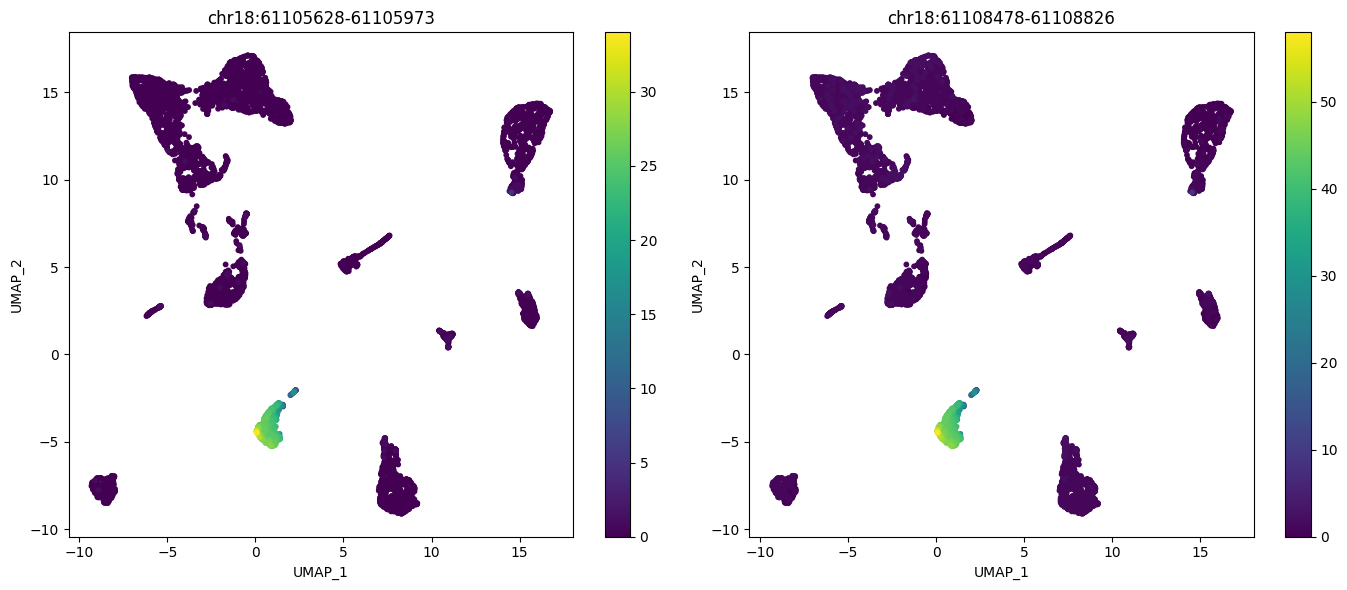

In [9]:
from pycisTopic.clust_vis import plot_imputed_features

plot_imputed_features(
    cistopic_obj,
    reduction_name="UMAP",
    imputed_data=imputed_acc,
    features=[CSF1R_PROMOTER, FIRE_ENHANCER],
    scale=False,
    num_columns=2,
    figsize=(14, 6),
)

In [10]:
import numpy as np

# Mean imputed accessibility of the Csf1r promoter per cluster
cluster_col = "leiden_10_0.6"
region_idx = list(imputed_acc.feature_names).index(CSF1R_PROMOTER)
values = np.asarray(imputed_acc.mtx[region_idx, :]).flatten()

df = pd.DataFrame({
    "cluster": cistopic_obj.cell_data[cluster_col].values,
    "csf1r": values,
})

means = df.groupby("cluster")["csf1r"].mean().sort_values(ascending=False)
print(means.head(10))
print()
print(f"Cells per cluster (top): \n{df['cluster'].value_counts().head(10)}")

cluster
6     23.040000
12     0.087379
14     0.076923
7      0.060172
13     0.054348
10     0.048544
2      0.043601
9      0.040650
11     0.018868
4      0.016187
Name: csf1r, dtype: float64

Cells per cluster (top): 
0    1152
1     879
2     711
3     560
4     556
5     464
6     350
7     349
9     246
8     246
Name: cluster, dtype: int64


In [11]:
tss_df = pd.read_csv(
    os.path.join(REPO_ROOT, "resources", "mm10_annotation.tsv"),
    sep="\t", index_col=0,
)

region_names = list(imputed_acc.feature_names)
reg_chrom = np.array([r.split(":")[0] for r in region_names])
reg_start = np.array([int(r.split(":")[1].split("-")[0]) for r in region_names])
reg_end = np.array([int(r.split(":")[1].split("-")[1]) for r in region_names])
region_names_arr = np.array(region_names)


def regions_near_gene(gene, window=10000):
    gene_rows = tss_df[tss_df["Gene"] == gene]
    selected = set()
    for _, row in gene_rows.iterrows():
        chrom, tss = str(row["Chromosome"]), int(row["Start"])
        mask = (
            (reg_chrom == chrom)
            & (reg_end >= tss - window)
            & (reg_start <= tss + window)
        )
        selected.update(region_names_arr[mask])
    return sorted(selected)


# Check on the known case
csf1r_regions = regions_near_gene("Csf1r")
print(f"Regions near Csf1r: {len(csf1r_regions)}")
print(f"FIRE enhancer included: {FIRE_ENHANCER in csf1r_regions}")

Regions near Csf1r: 17
FIRE enhancer included: True


In [12]:
markers = {
    "Csf1r": "Microglia",
    "Cx3cr1": "Microglia",
    "Aqp4": "Astrocytes",
    "Gja1": "Astrocytes",
    "Mbp": "Oligodendrocytes",
    "Plp1": "Oligodendrocytes",
    "Pdgfra": "OPC",
    "Cspg4": "OPC",
    "Slc17a7": "Excitatory neurons",
    "Satb2": "Excitatory neurons",
    "Gad1": "Inhibitory neurons",
    "Gad2": "Inhibitory neurons",
    "Cldn5": "Endothelial",
    "Flt1": "Endothelial",
}

cluster_col = "leiden_10_0.6"
clusters = cistopic_obj.cell_data[cluster_col].values
unique_clusters = sorted(set(clusters), key=lambda x: int(x))

rows = []
for gene, cell_type in markers.items():
    regions = regions_near_gene(gene)
    if not regions:
        print(f"WARNING: no regions found for {gene}")
        continue
    idx = [region_names.index(r) for r in regions]
    signal = np.asarray(imputed_acc.mtx[idx, :]).mean(axis=0)
    per_cluster = [signal[clusters == c].mean() for c in unique_clusters]
    rows.append(pd.Series(per_cluster, index=unique_clusters, name=f"{gene} ({cell_type})"))

marker_matrix = pd.DataFrame(rows)

# Row-wise z-score
zscores = marker_matrix.sub(marker_matrix.mean(axis=1), axis=0).div(
    marker_matrix.std(axis=1), axis=0
)

print(zscores.round(2))

                                 0     1     2     3     4     5     6     7  \
Csf1r (Microglia)            -0.27 -0.27 -0.29 -0.25 -0.28 -0.27  3.61 -0.14   
Cx3cr1 (Microglia)           -0.35 -0.37 -0.09 -0.36 -0.37 -0.22  3.59 -0.25   
Aqp4 (Astrocytes)            -0.46 -0.47 -0.45 -0.47 -0.47  2.77 -0.45 -0.46   
Gja1 (Astrocytes)            -0.49 -0.48 -0.59 -0.49 -0.51  2.65 -0.51 -0.46   
Mbp (Oligodendrocytes)        0.05  0.08  3.39  0.08 -0.13 -0.80 -0.33 -0.33   
Plp1 (Oligodendrocytes)      -0.44 -0.41  3.51 -0.40 -0.37 -0.20 -0.38 -0.32   
Pdgfra (OPC)                 -0.77 -0.55 -0.41 -0.68 -0.62  1.16 -0.02 -0.51   
Cspg4 (OPC)                  -0.22 -0.29 -0.71  0.20  0.59  0.49 -1.44 -1.06   
Slc17a7 (Excitatory neurons)  0.62  1.35  0.05  1.33  1.51 -0.92 -0.72 -1.06   
Satb2 (Excitatory neurons)    1.38  1.81 -0.85  1.26  0.26 -0.24  0.80 -0.98   
Gad1 (Inhibitory neurons)    -0.60 -0.61 -0.59 -0.58 -0.53  0.02 -0.64  2.08   
Gad2 (Inhibitory neurons)    -0.42 -0.41

In [13]:
cell_type_by_marker = {gene: ct for gene, ct in markers.items()}

assignments = {}
for cluster in zscores.columns:
    top_marker = zscores[cluster].idxmax()
    gene = top_marker.split(" (")[0]
    assignments[cluster] = cell_type_by_marker[gene]
    n_cells = (clusters == cluster).sum()
    print(f"Cluster {cluster:>2} ({n_cells:>4} cells): {gene:<8} -> {cell_type_by_marker[gene]:<20} (z={zscores.loc[top_marker, cluster]:.2f})")

cistopic_obj.cell_data["cell_type"] = [assignments[c] for c in clusters]

with open(CTO_PATH, "wb") as f:
    pickle.dump(cistopic_obj, f, protocol=pickle.HIGHEST_PROTOCOL)

print()
print(cistopic_obj.cell_data["cell_type"].value_counts())

Cluster  0 (1152 cells): Satb2    -> Excitatory neurons   (z=1.38)
Cluster  1 ( 879 cells): Satb2    -> Excitatory neurons   (z=1.81)
Cluster  2 ( 711 cells): Plp1     -> Oligodendrocytes     (z=3.51)
Cluster  3 ( 560 cells): Slc17a7  -> Excitatory neurons   (z=1.33)
Cluster  4 ( 556 cells): Slc17a7  -> Excitatory neurons   (z=1.51)
Cluster  5 ( 464 cells): Aqp4     -> Astrocytes           (z=2.77)
Cluster  6 ( 350 cells): Csf1r    -> Microglia            (z=3.61)
Cluster  7 ( 349 cells): Gad1     -> Inhibitory neurons   (z=2.08)
Cluster  8 ( 246 cells): Gad2     -> Inhibitory neurons   (z=2.88)
Cluster  9 ( 246 cells): Pdgfra   -> OPC                  (z=3.01)
Cluster 10 ( 206 cells): Aqp4     -> Astrocytes           (z=2.06)
Cluster 11 ( 106 cells): Slc17a7  -> Excitatory neurons   (z=0.28)
Cluster 12 ( 103 cells): Cldn5    -> Endothelial          (z=3.60)
Cluster 13 (  92 cells): Slc17a7  -> Excitatory neurons   (z=0.43)
Cluster 14 (  91 cells): Slc17a7  -> Excitatory neurons   (z=1

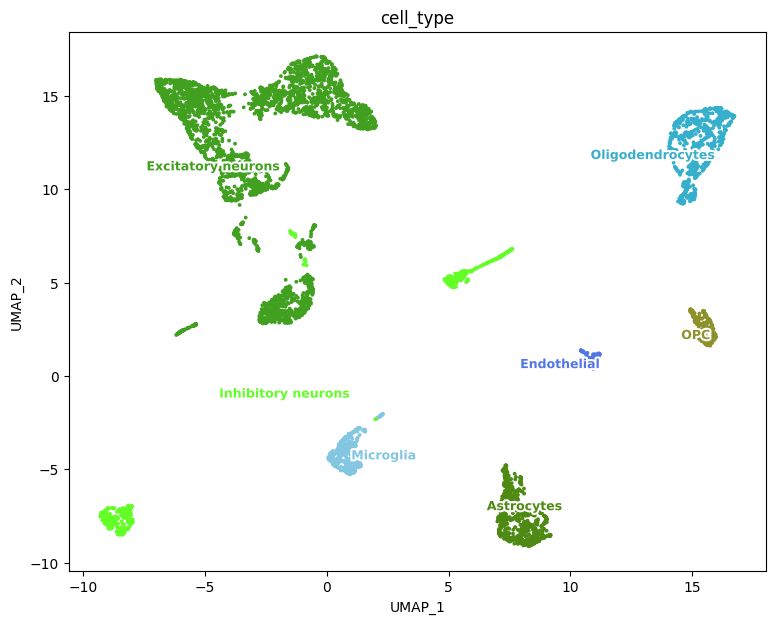

In [14]:
from pycisTopic.clust_vis import plot_metadata

plot_metadata(
    cistopic_obj,
    reduction_name="UMAP",
    variables=["cell_type"],
    target="cell",
    num_columns=1,
    text_size=9,
    dot_size=3,
    figsize=(9, 7),
)